## Deconvolution using geneformer (pseudobulk + single-cell reference) - Geneformer
This tutorial demonstrates how to use DECONVersation to run and evaluate deconvolution on pseudobulk data, using built-in pseudobulk simulation functions available within the package. Geneformer embeddings are used throughout, though the workflow is fully adaptable to Cell2Sentence or CellHermes. The tutorial covers the full pipeline: generating pseudobulk data, constructing signature matrices, extracting Geneformer embeddings from both the pseudobulk and single-cell reference signature datasets, and estimating cell type proportions via NNLS. Predicted proportions are then evaluated against ground truth using RMSE and Pearson correlation to benchmark deconvolution performance. <br>

### Step 0: Load reference data (scRNA-seq)

In [1]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
sys.path.append('../deconversation')

/nfs/home/aoku/.local/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
# Import associated modules
from pseudobulk import *
from preprocessing import *

In [3]:
# Path to single-cell RNAseq data 
path = "/gpfs/commons/groups/compbio/projects/CZI_endom/publicData/HECA/endometriumAtlasV2_cells_with_counts.h5ad"
path_ref = "/gpfs/commons/groups/compbio/projects/CZI_endom/publicData/HECA/endometriumAtlasV2_nuclei.h5ad"

### Step 1: Prep data for Geneformer

In [4]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

# Subset to select cell types
adata = adata[adata.obs["dataset"].isin(['Mareckova'])]
adata = adata[adata.obs["celltype"].isin(['eStromal', 'dStromal_mid', 'Immune_Lymphoid', 
                                          'dStromal_early', 'Venous', 'eHormones', 'Glandular', 
                                          'SOX9_functionalis_II', 'preGlandular'])]

# Remove unmapped genes
adata.var.index = adata.var["gene_ids-0-Fonseca"]
adata = adata[:, adata.var.index != "nan"]
adata = adata[:, adata.var.index.notnull()]

/scratch/ipykernel_1747466/3145637199.py:11: ImplicitModificationWarning: Trying to modify index of attribute `.var` of view, initializing view as actual.
  adata.var.index = adata.var["gene_ids-0-Fonseca"]
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [5]:
adata.obs["celltype"].value_counts()

celltype
eStromal                14370
dStromal_early           8711
dStromal_mid             8036
SOX9_functionalis_II     5502
preGlandular             5079
Immune_Lymphoid          4354
eHormones                4032
Glandular                3755
Venous                   3206
Name: count, dtype: int64

In [6]:
# Read the h5ad file (just to explore columns and variables)
adata_ref = sc.read_h5ad(path_ref)

# # Subset to select cell types
adata_ref = adata_ref[adata_ref.obs["celltype"].isin(['eStromal', 'dStromal_mid', 'Immune_Lymphoid', 
                                          'dStromal_early', 'Venous', 'eHormones', 'Glandular', 
                                          'SOX9_functionalis_II', 'preGlandular'])]

# Remove unmapped genes
adata_ref.var.index = adata_ref.var["gene_ids-0"]
adata_ref = adata_ref[:, adata_ref.var.index != "nan"]
adata_ref = adata_ref[:, adata_ref.var.index.notnull()]

/scratch/ipykernel_1747466/2946851785.py:10: ImplicitModificationWarning: Trying to modify index of attribute `.var` of view, initializing view as actual.
  adata_ref.var.index = adata_ref.var["gene_ids-0"]
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [7]:
adata_ref.obs["celltype"].value_counts()

celltype
eStromal                46062
SOX9_functionalis_II    38538
preGlandular            18101
Immune_Lymphoid         16948
dStromal_early          16576
Glandular               15355
dStromal_mid            13676
eHormones               13459
Venous                   3394
Name: count, dtype: int64

/nfs/home/aoku/.local/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


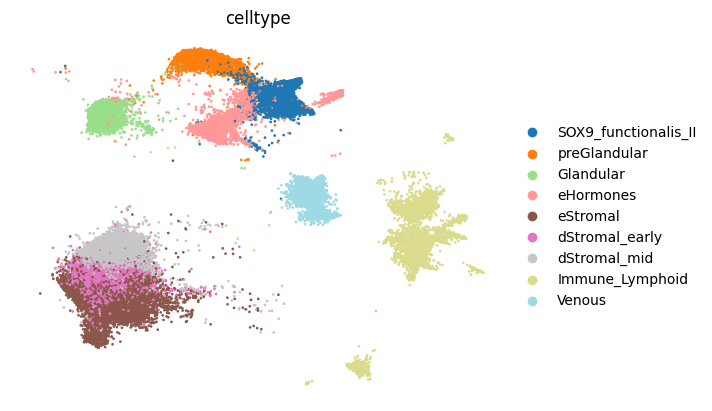

In [8]:
sc.pl.umap(adata, color='celltype', frameon=False, size=15, palette='tab20')

/nfs/home/aoku/.local/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


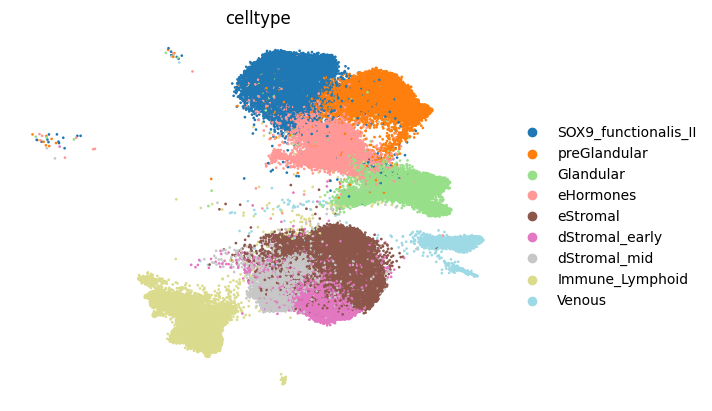

In [9]:
sc.pl.umap(adata_ref, color='celltype', frameon=False, size=15, palette='tab20')

### Step 2: Create pseudobulk

In [10]:
# Create pseudobulk and cell type prortions (ground truth)
pseudo_bulk, cell_prop = generate_pseudobulk(adata = adata,
                                             cell_type_col = "celltype", 
                                             n_pseudobulks = 500,
                                             target_proportion_min = 0.10, 
                                             target_proportion_max = 0.80, 
                                             n_cells_per_pseudobulk = 1000, 
                                             random_state = 42 
                                            )

In [11]:
pseudo_bulk.head()

gene_ids-0-Fonseca,ENSG00000121410,ENSG00000175899,ENSG00000128274,ENSG00000094914,ENSG00000081760,ENSG00000109576,ENSG00000103591,ENSG00000115977,ENSG00000087884,ENSG00000127837,...,ENSG00000214655,ENSG00000185453,ENSG00000086827,ENSG00000174442,ENSG00000198205,ENSG00000198455,ENSG00000070476,ENSG00000162378,ENSG00000159840,ENSG00000074755
SOX9_functionalis_II_PB1,157.315033,217.779404,139.927643,107.392952,102.560364,101.420441,127.671265,283.776184,258.739227,313.969696,...,146.126083,43.599747,57.166832,57.903728,14.078470,37.190372,82.945396,264.960083,447.041168,128.092850
dStromal_mid_PB2,222.859879,295.543610,82.930138,120.276207,89.394379,102.177216,52.771145,361.302551,175.868866,273.345886,...,126.194000,54.351410,51.662312,39.830914,7.765866,36.496849,79.533569,348.799011,897.262024,140.834000
Venous_PB3,140.549744,1930.760864,318.499359,120.153114,78.342400,36.936054,103.976341,342.703369,309.126221,332.337402,...,176.314072,60.750175,77.074524,50.183838,17.973970,41.342766,111.626625,259.191498,573.099792,212.046570
preGlandular_PB4,93.298836,210.397003,105.085770,111.030220,89.179169,153.511993,101.492676,211.107651,304.612610,325.533844,...,152.752090,30.382133,57.375053,46.173111,17.540382,30.832708,83.077766,227.581024,362.392578,142.699844
eHormones_PB5,154.714828,320.047028,142.140656,114.081505,79.971527,90.718605,109.743820,314.191925,241.653870,286.178741,...,153.945084,73.117867,56.246273,65.009430,15.297888,37.697624,82.605522,257.303619,524.480652,143.121307


In [12]:
#pseudo_bulk.to_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/scripts/pseudobulk_data_heca_Mareckova_single_cell_only.csv")

### Step 3: Create signature matrix

In [13]:
# Create signature matrix from single cell data
sig_mat = create_signature_matrix(adata = adata_ref,
                                  sample_col = "sample", # sample id column
                                  cell_type_col = "celltype",
                                  groupby = "celltype",
                                  sample_ids = None,
                                  output_path = None)

# Transpose for embedding extraction
# Columns should be gene names or ensembl ids (ensembl ids for geneformer)
sig_mat = sig_mat.T

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/preprocessing.py:246: UserWarning: Expression matrix contains non-integer values. Raw counts are expected. 
  warnings.warn(
/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/preprocessing.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature = expr.groupby(groupby).mean().T


In [14]:
sig_mat.head()

gene_ids-0,ENSG00000121410,ENSG00000268895,ENSG00000148584,ENSG00000175899,ENSG00000245105,ENSG00000166535,ENSG00000256661,ENSG00000184389,ENSG00000128274,ENSG00000118017,...,ENSG00000086827,ENSG00000174442,ENSG00000122952,ENSG00000198205,ENSG00000198455,ENSG00000070476,ENSG00000203995,ENSG00000162378,ENSG00000159840,ENSG00000074755
celltype,,,,,,,,,,,,,,,,,,,,,
SOX9_functionalis_II,0.031350,0.010910,0.003604,0.085364,0.009395,0.018540,0.315712,0.001889,0.201908,0.000048,...,0.144578,0.087287,0.027259,0.003856,0.011537,0.452550,0.009015,0.372470,0.111210,0.422845
preGlandular,0.031814,0.009524,0.000541,0.108921,0.007264,0.038818,0.227653,0.001538,0.080537,0.000178,...,0.145544,0.084857,0.033549,0.004436,0.010733,0.409723,0.026528,0.321887,0.118353,0.493830
Glandular,0.036877,0.011069,0.002028,0.204764,0.004437,0.022719,1.958125,0.003486,0.139029,0.000059,...,0.141178,0.080666,0.010566,0.004593,0.009883,0.521152,0.007031,0.332832,0.157526,0.583567
eHormones,0.035515,0.014339,0.001955,0.116688,0.008188,0.017235,0.484939,0.003349,0.194835,0.000148,...,0.145207,0.090055,0.023039,0.004852,0.014022,0.541487,0.006449,0.391435,0.164065,0.448435
eStromal,0.093458,0.085751,0.000880,0.129728,0.022028,0.011167,0.069346,0.006646,0.069730,0.001059,...,0.124160,0.073676,0.020734,0.004784,0.012763,0.382653,0.005754,0.559452,0.307520,0.448205


The signature matrix is constructed by averaging gene expression across the selected cell types, requiring no predefined gene markers. To build a signature matrix from a specific subset of samples, pass the desired sample IDs as a list. Here, all available samples are used, so `sample_id` is set to None.

### Step 4: Extract Geneformer Embeddings

In [15]:
from embeddings import *

geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.


In [16]:
sig_mat_gf_embed = extract_embs(
    bulk_df = sig_mat, # sample x ensembl id
    mode = "geneformer", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer", # Default geneformer model
    layer_to_quant = 18,
    delete_temp_files = True # if True, delete all temporary files created whiile extracting embeddings
)

Bulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  9.93it/s]
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:740: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['SOX9_functionalis_II', 'preGlandular', 'Glandular', 'eHormones', 'eStromal']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/commons/group

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Loading Geneformer model...


CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

In [17]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, # sample x ensembl id
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer", # Default geneformer model
    layer_to_quant = 18,
    delete_temp_files = True
)

Bulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 16.29it/s]
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Loading Geneformer model...


CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/10 [00:00<?, ?it/s]

### Step 5: Run Non-Negative Least Squares (NNLS)

In [18]:
from deconvolution import *

In [19]:
# Run NNLS
results = run_all_deconv(bulk_df=pseudo_bulk_embed.T, signature_df=sig_mat_gf_embed.T)

Condition number: 40.54.
~1-10: signatures are well separated; NNLS is usually hard to improve materially with another solver.
Smallest singular value: 0.07136.
If value is close to zero, the signature matrix is ill-conditioned; estimated proportions may be unstable.
Max pairwise cosine similarity between cell types: 0.9934.
Most similar pair: eStromal vs dStromal_early.
If value is close to 1, these cell types are highly similar and difficult to resolve separately.
Running solver: nnls
Finished in 0.11 seconds.
Running solver: nnls_mod
Finished in 0.12 seconds.
Running solver: dwls
Finished in 0.91 seconds.
Running solver: simplex
Finished in 1.00 seconds.
Running solver: ridge_simplex
Finished in 1.12 seconds.
Running solver: dwls_simplex
Finished in 2.16 seconds.
Running solver: ridge
Finished in 13.31 seconds.
Running solver: elasticnet
Finished in 0.20 seconds.
Running solver: nusvr
Finished in 17.94 seconds.
Running solver: simplex_nnls
Finished in 0.28 seconds.
Running solver: g

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/deconvolution.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  references = torch.tensor(references, dtype=torch.float32)
/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/deconvolution.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mixture = torch.tensor(mixture, dtype=torch.float32)


Finished in 1.26 seconds.


In [20]:
cell_prop_pred = results["elasticnet"]

### Step 6: Evaluate estimated proportions

In [21]:
from evaluation import *

In [22]:
corr = pd.DataFrame(compute_correlation(true_df=cell_prop, 
                    pred_df=cell_prop_pred, 
                    return_per_celltype=True))
corr.columns = ["corr_overall", "corr_per_celltype"]

rmse = pd.DataFrame(compute_rmse(true_df=cell_prop, 
                    pred_df=cell_prop_pred, 
                    return_per_celltype=True))
rmse.columns = ["rmse_overall", "rmse_per_celltype"]

pd.concat([corr, rmse], axis=1)

,corr_overall,corr_per_celltype,rmse_overall,rmse_per_celltype
eStromal,0.561773,0.577040,0.126765,0.126741
Venous,0.561773,0.968673,0.126765,0.054155
preGlandular,0.561773,0.568501,0.126765,0.169782
Immune_Lymphoid,0.561773,0.827078,0.126765,0.114976
eHormones,0.561773,0.644288,0.126765,0.128179
SOX9_functionalis_II,0.561773,0.492456,0.126765,0.132396
dStromal_mid,0.561773,0.533897,0.126765,0.146809
dStromal_early,0.561773,0.456770,0.126765,0.130014
Glandular,0.561773,0.669611,0.126765,0.105681


In [23]:
from visualization import *

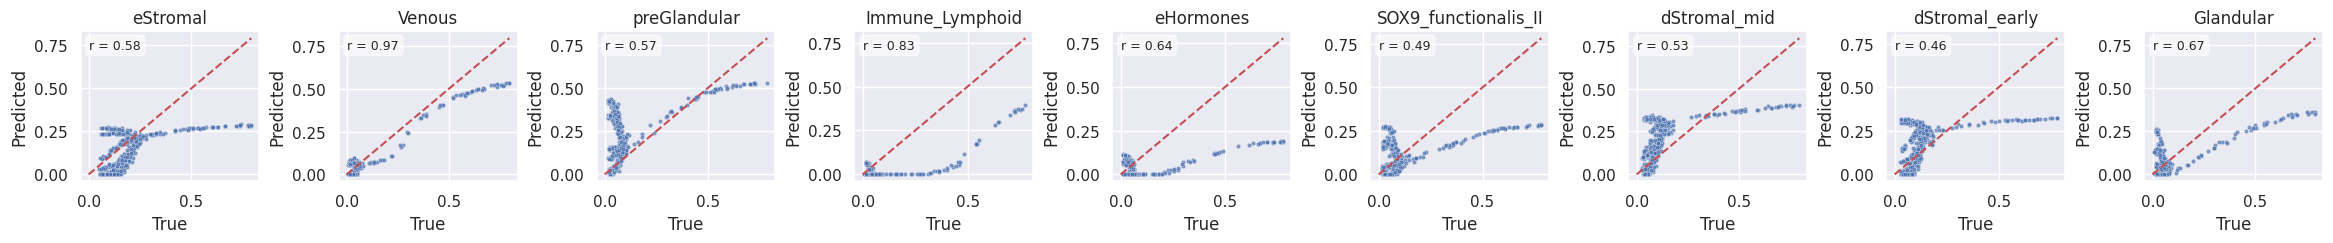

In [24]:
plot_true_vs_predicted(
    y_true_df = cell_prop, # sample (rows) x cell type (columns)
    y_pred_df = cell_prop_pred, # sample (rows) x cell type (columns)
    stratify_by_celltype= True,
    dot_size = 10,n_cols=9,
    figsize_per_plot = (2.6,2.6)
)

### Counts

In [25]:
# Run NNLS
results_counts = run_all_deconv(bulk_df=pseudo_bulk.T, signature_df=sig_mat.T, solvers=["nnls", "elasticnet"])

Condition number: 22.23.
~1-10: signatures are well separated; NNLS is usually hard to improve materially with another solver.
Smallest singular value: 0.1263.
If value is close to zero, the signature matrix is ill-conditioned; estimated proportions may be unstable.
Max pairwise cosine similarity between cell types: 0.9739.
Most similar pair: eStromal vs dStromal_early.
If value is close to 1, these cell types are highly similar and difficult to resolve separately.
Running solver: nnls
Finished in 0.90 seconds.
Running solver: elasticnet
Finished in 2.25 seconds.


In [26]:
cell_prop_pred = results_counts["elasticnet"]

In [27]:
corr = pd.DataFrame(compute_correlation(true_df=cell_prop, 
                    pred_df=cell_prop_pred, 
                    return_per_celltype=True))
corr.columns = ["corr_overall", "corr_per_celltype"]

rmse = pd.DataFrame(compute_rmse(true_df=cell_prop, 
                    pred_df=cell_prop_pred, 
                    return_per_celltype=True))
rmse.columns = ["rmse_overall", "rmse_per_celltype"]

pd.concat([corr, rmse], axis=1)

,corr_overall,corr_per_celltype,rmse_overall,rmse_per_celltype
eStromal,0.282701,0.769258,0.148558,0.177259
Venous,0.282701,0.982636,0.148558,0.130878
preGlandular,0.282701,0.786444,0.148558,0.135397
Immune_Lymphoid,0.282701,0.969034,0.148558,0.141611
eHormones,0.282701,0.832771,0.148558,0.159305
SOX9_functionalis_II,0.282701,0.852855,0.148558,0.140866
dStromal_mid,0.282701,0.775058,0.148558,0.201637
dStromal_early,0.282701,0.575258,0.148558,0.111345
Glandular,0.282701,0.784687,0.148558,0.115811


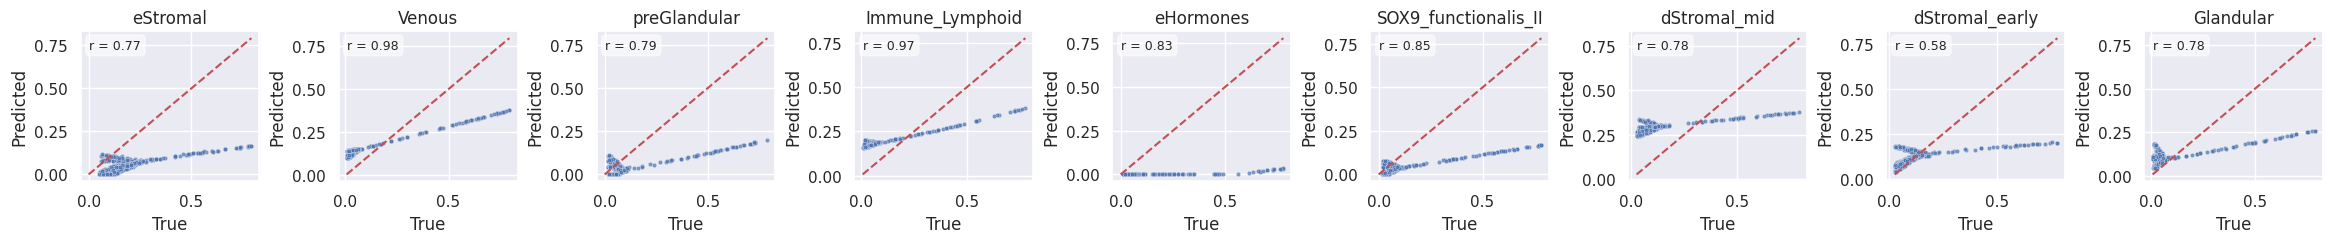

In [28]:
plot_true_vs_predicted(
    y_true_df = cell_prop, # sample (rows) x cell type (columns)
    y_pred_df = cell_prop_pred, # sample (rows) x cell type (columns)
    stratify_by_celltype= True,
    dot_size = 10,n_cols=9,
    figsize_per_plot = (2.6,2.6)
)

### MuSiC

In [29]:
music_results = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/results/MuSiC_estimated_proportions_HECA_single_nuc_ref.csv", index_col=0)

In [32]:
corr = pd.DataFrame(compute_correlation(true_df=cell_prop, 
                    pred_df=music_results, 
                    return_per_celltype=True))
corr.columns = ["corr_overall", "corr_per_celltype"]

rmse = pd.DataFrame(compute_rmse(true_df=cell_prop, 
                    pred_df=music_results, 
                    return_per_celltype=True))
rmse.columns = ["rmse_overall", "rmse_per_celltype"]

pd.concat([corr, rmse], axis=1)

/nfs/home/aoku/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/nfs/home/aoku/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,corr_overall,corr_per_celltype,rmse_overall,rmse_per_celltype
eStromal,0.415086,NaN,0.206014,0.237393
Venous,0.415086,0.994926,0.206014,0.051112
preGlandular,0.415086,0.892332,0.206014,0.070794
Immune_Lymphoid,0.415086,0.966556,0.206014,0.089790
eHormones,0.415086,0.680001,0.206014,0.154228
SOX9_functionalis_II,0.415086,0.725663,0.206014,0.113206
dStromal_mid,0.415086,0.535701,0.206014,0.482719
dStromal_early,0.415086,0.657771,0.206014,0.153499
Glandular,0.415086,0.859361,0.206014,0.129432


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/visualization.py:159: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(x, y)


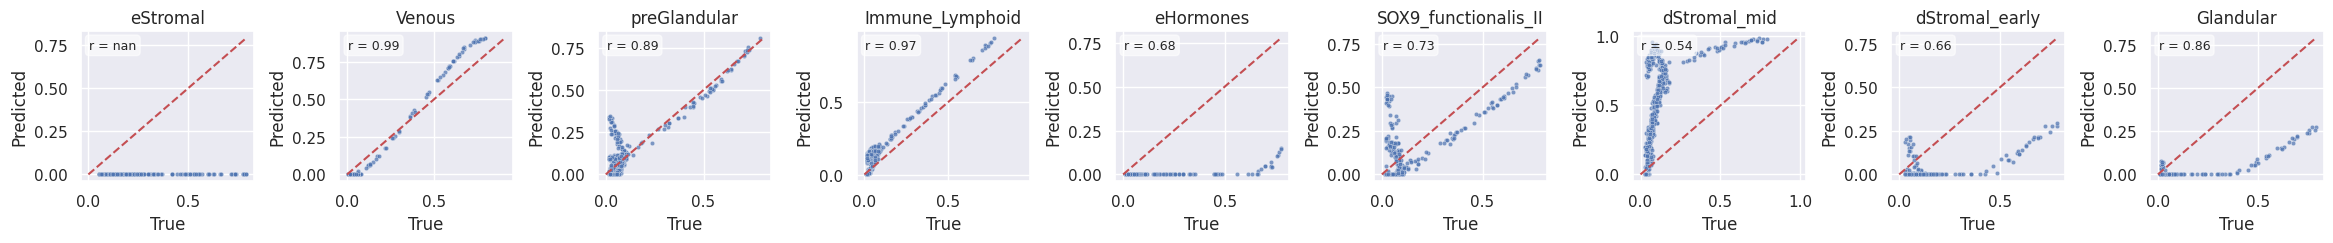

In [31]:
plot_true_vs_predicted(
    y_true_df = cell_prop, # sample (rows) x cell type (columns)
    y_pred_df = music_results, # sample (rows) x cell type (columns)
    stratify_by_celltype= True,
    dot_size = 10,n_cols=9,
    figsize_per_plot = (2.6,2.6)
)